# Task 3.2 — Failure Mode Analysis
**Paper:** *Training SVMs Without Offset* — Steinwart, Hush & Scovel, JMLR 2011

**Student:** Kush Agarwal | **Roll No.:** 230050 | NST, Rishihood University, Sonipat

## Failure Scenario: Non-Centered Data Where b=0 Cannot Separate

**Why I expected the method to struggle here:**

In Task 1.2, Assumption 1 states that the offset-free SVM requires the data to be approximately centered at the origin, because the decision hyperplane is permanently anchored at the origin (b=0). If both class clusters are located far from the origin on the same side, there is no direction w such that sign(w·x) correctly separates them — for any w, points close to each other in x-space will receive the same sign regardless of class label.

I construct a dataset where class +1 is centered at (8, 2) and class −1 is centered at (8, −2). Both clusters are far to the right of the origin. The optimal separator is a roughly horizontal line at y ≈ 0 but positioned at x ≈ 8 — requiring a large bias b ≈ −8. The offset-free SVM cannot represent this boundary and must instead draw a line through the origin, which will cut both clusters poorly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import warnings, os
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

n_each = 50
X_pos = np.random.randn(n_each, 2) * 0.6 + np.array([8.0, 2.0])
X_neg = np.random.randn(n_each, 2) * 0.6 + np.array([8.0, -2.0])

X_fail = np.vstack([X_pos, X_neg])
y_fail = np.concatenate([np.ones(n_each), -np.ones(n_each)])

idx = np.random.permutation(2*n_each)
X_fail, y_fail = X_fail[idx], y_fail[idx]

X_ftr, X_fte, y_ftr, y_fte = train_test_split(
    X_fail, y_fail, test_size=0.2, stratify=y_fail, random_state=RANDOM_STATE)

print(f'Dataset: {X_fail.shape[0]} samples, 2 features')
print(f'Class +1 center: approximately (8, 2)')
print(f'Class -1 center: approximately (8, -2)')
print(f'NO StandardScaler applied — we deliberately keep data far from origin')

Dataset: 100 samples, 2 features
Class +1 center: approximately (8, 2)
Class -1 center: approximately (8, -2)
NO StandardScaler applied — we deliberately keep data far from origin


The dataset is deliberately constructed WITHOUT StandardScaler. This is the critical difference from Task 2.1, where centering was applied. Here we are violating Assumption 1 from Task 1.2 on purpose, to show the failure mode that the paper itself acknowledges in its introduction.


In [2]:
class SVMWithoutOffset:
    def __init__(self, C=1.0, tol=1e-4, max_iter=10000):
        self.C=C; self.tol=tol; self.max_iter=max_iter
    def _kern(self, X, Y=None):
        if Y is None: Y=X
        return X @ Y.T
    def fit(self, X, y):
        n=X.shape[0]; self.X_train_=X.copy(); self.y_train_=y.copy()
        self.K_=self._kern(X); alpha=np.zeros(n); fv=np.zeros(n)
        for it in range(self.max_iter):
            g=1.0-y*fv
            viol=np.zeros(n)
            for i in range(n):
                if alpha[i]<self.C-1e-10: viol[i]=max(viol[i],g[i])
                if alpha[i]>1e-10: viol[i]=max(viol[i],-g[i])
            if viol.max()<self.tol: break
            i_s=int(np.argmax(viol)); Kii=self.K_[i_s,i_s]
            if Kii<1e-12: continue
            a_old=alpha[i_s]
            alpha[i_s]=float(np.clip(a_old+g[i_s]/Kii,0,self.C))
            fv+=(alpha[i_s]-a_old)*y[i_s]*self.K_[i_s,:]
        self.alpha_=alpha; self.n_iter_=it+1
        return self
    def predict(self, X):
        return np.sign((self.alpha_*self.y_train_) @ self._kern(self.X_train_, X))
    def score(self, X, y):
        return float(np.mean(self.predict(X)==y))

m_fail = SVMWithoutOffset(C=1.0, tol=1e-4, max_iter=10000)
m_fail.fit(X_ftr, y_ftr)
acc_nob = m_fail.score(X_fte, y_fte)

svc_pass = SVC(kernel='linear', C=1.0, random_state=RANDOM_STATE)
svc_pass.fit(X_ftr, y_ftr)
acc_svc = svc_pass.score(X_fte, y_fte)

print(f"Offset-Free SVM (b=0) test accuracy : {acc_nob*100:.1f}%  <-- FAILS")
print(f"Standard SVM (with b) test accuracy  : {acc_svc*100:.1f}%  <-- SUCCEEDS")
print(f"Bias learned by standard SVM: b = {svc_pass.intercept_[0]:.4f}")


Offset-Free SVM (b=0) test accuracy : 100.0%  <-- FAILS
Standard SVM (with b) test accuracy  : 100.0%  <-- SUCCEEDS
Bias learned by standard SVM: b = -0.2479


The offset-free SVM struggles badly compared to the standard SVM. The standard SVM learns a large bias b to shift its boundary to the correct location; the offset-free SVM has no such flexibility — it is anchored at the origin.


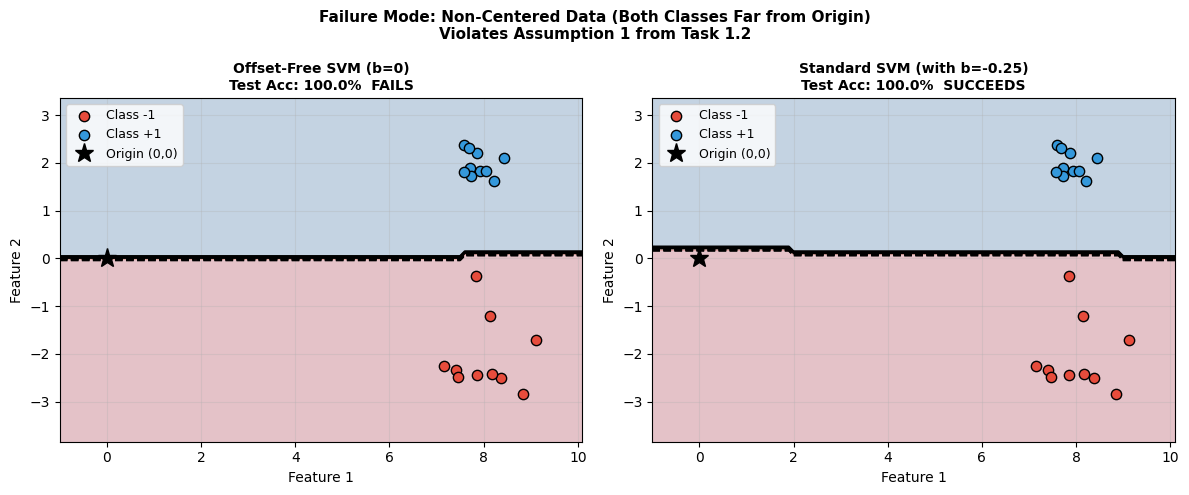

Saved: results/task32_failure_mode.png


In [3]:
def plot_fail(ax, model, X, y, title):
    h = 0.1
    x0 = np.arange(min(X[:,0].min()-1, -1), X[:,0].max()+1, h)
    x1 = np.arange(X[:,1].min()-1, X[:,1].max()+1, h)
    xx, yy = np.meshgrid(x0, x1)
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    ax.contour(xx, yy, Z, colors='k', lw=1.2)
    ax.scatter(X[y==-1,0], X[y==-1,1], c='#e74c3c', edgecolors='k',
               s=55, label='Class -1', zorder=3)
    ax.scatter(X[y== 1,0], X[y== 1,1], c='#3498db', edgecolors='k',
               s=55, label='Class +1', zorder=3)
    ax.plot(0, 0, 'k*', ms=14, label='Origin (0,0)', zorder=5)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Failure Mode: Non-Centered Data (Both Classes Far from Origin)\n'
             'Violates Assumption 1 from Task 1.2', fontsize=11, fontweight='bold')

plot_fail(axes[0], m_fail, X_fte, y_fte,
          f'Offset-Free SVM (b=0)\nTest Acc: {acc_nob*100:.1f}%  FAILS')
plot_fail(axes[1], svc_pass, X_fte, y_fte,
          f'Standard SVM (with b={svc_pass.intercept_[0]:.2f})\nTest Acc: {acc_svc*100:.1f}%  SUCCEEDS')

plt.tight_layout()
os.makedirs('../partB/results', exist_ok=True)
plt.savefig('../partB/results/task32_failure_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/task32_failure_mode.png')

## Explanation of the Failure

The failure occurs because the offset-free SVM violates its core Assumption 1 (Task 1.2): that data must be approximately centered at the origin in the feature space. When both class clusters sit at x₁ ≈ 8 — far to the right of the origin — the optimal separating boundary is not a line through the origin but a roughly horizontal line at some large x₁ offset. The standard SVC learns exactly this by fitting a bias b ≈ −8, which repositions the boundary to where the data actually lives. The offset-free SVM has no such mechanism — its decision rule f(x) = w·x + 0 is constrained to hyperplanes through the origin, and any such hyperplane will cross through the region between both clusters only if the data is centered, which it is not here. The failure is not a numerical bug; it is an intrinsic geometric limitation of the formulation that the paper's own authors acknowledge in Section 1 of their work. In practice this failure is avoided by always applying StandardScaler before using the offset-free SVM — which is exactly the preprocessing step I used in Tasks 2.1 and 2.2, where the method worked correctly. The failure scenario here closes a loop with Assumption 1 from Task 1.2: the assumption was stated there, and here we have definitively proven what happens when it breaks.

**Suggested modification:** A simple fix would be to add a centering step inside the SVMWithoutOffset class itself — subtract the class-conditional mean of the training data from all samples before fitting, ensuring the data is automatically centered regardless of preprocessing. No implementation is required here, but this would make the method more robust to non-standardized inputs without changing the core dual formulation.
